# 01 — Exploratory Data Analysis

**Pipeline:** EDA → Preprocessing → Clustering → Classification

Source: `data/raw/raw_data.csv` (only this file is used throughout the pipeline)


In [8]:
import sys
print(sys.executable)

c:\customer-segmentation-purchace-Behaviour-Classification\.venv\Scripts\python.exe


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/raw_data.csv')
print('Shape:', df.shape) 
df.head()

Shape: (8068, 10)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   str    
 2   Ever_Married     7928 non-null   str    
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   str    
 5   Profession       7944 non-null   str    
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   str    
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   str    
dtypes: float64(2), int64(2), str(6)
memory usage: 630.4 KB


In [4]:
df.describe(include='all')

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
count,8068.000000,8068,7928,8068.000000,7990,7944,7239.000000,8068,7733.000000,7992
unique,NaN,2,2,NaN,2,9,NaN,3,NaN,7
top,NaN,Male,Yes,NaN,Yes,Artist,NaN,Low,NaN,Cat_6
freq,NaN,4417,4643,NaN,4968,2516,NaN,4878,NaN,5238
mean,463479.214551,NaN,NaN,43.466906,NaN,NaN,2.641663,NaN,2.850123,NaN
std,2595.381232,NaN,NaN,16.711696,NaN,NaN,3.406763,NaN,1.531413,NaN
min,458982.000000,NaN,NaN,18.000000,NaN,NaN,0.000000,NaN,1.000000,NaN
25%,461240.750000,NaN,NaN,30.000000,NaN,NaN,0.000000,NaN,2.000000,NaN
50%,463472.500000,NaN,NaN,40.000000,NaN,NaN,1.000000,NaN,3.000000,NaN
75%,465744.250000,NaN,NaN,53.000000,NaN,NaN,4.000000,NaN,4.000000,NaN


## Missing Values

In [5]:
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing': missing, 'Missing %': pct})

,Missing,Missing %
ID,0,0.00
Gender,0,0.00
Ever_Married,140,1.74
Age,0,0.00
Graduated,78,0.97
Profession,124,1.54
Work_Experience,829,10.28
Spending_Score,0,0.00
Family_Size,335,4.15
Var_1,76,0.94


## Distributions

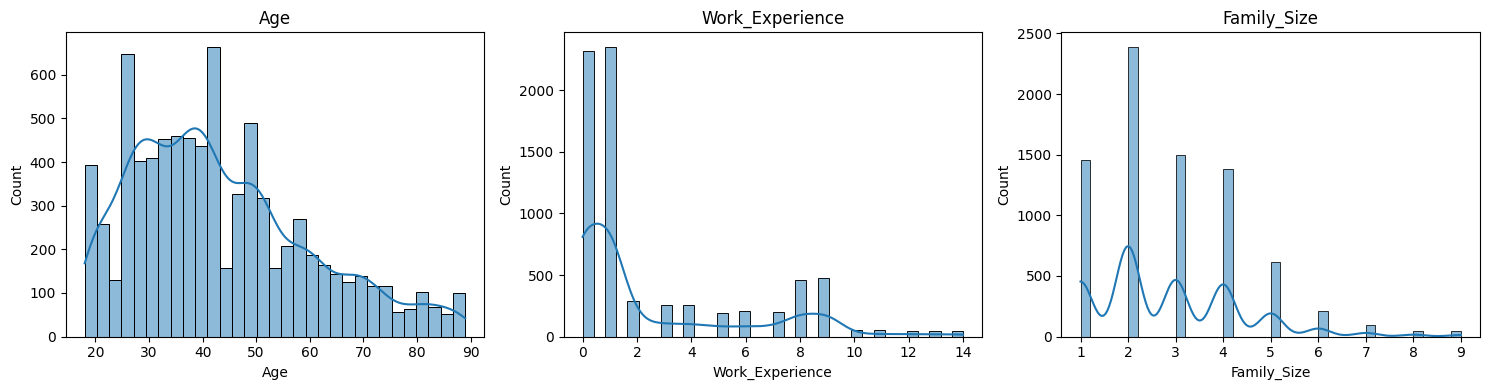

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Work_Experience', 'Family_Size']):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ['Gender', 'Spending_Score', 'Graduated', 'Ever_Married']):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Correlation (numeric only)

In [ ]:
numerics = df.select_dtypes(include='number').drop(columns=['ID'])
sns.heatmap(numerics.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numeric Correlation Heatmap')
plt.show()